# ARIMA-LSTM: выбор на validation

Notebook строит псевдовневыборочные остатки зафиксированной ARIMA, выполняет отдельный LSTM grid на остатках и сравнивает аддитивный гибрид с `naive_zero`, ARIMA и обычной LSTM. Final test остаётся закрытым.

In [1]:
import sys
from collections.abc import Mapping
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import clear_output, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from evaluation.arima_lstm import (  # noqa: E402
    RESIDUAL_MODEL_NAME,
    build_arima_lstm_predictions,
)
from evaluation.arima_residuals import (  # noqa: E402
    ARIMA_RESIDUAL_WARMUP,
    FIXED_ARIMA_ORDERS,
)
from evaluation.contracts import BPS_FACTOR, EVALUATION_SPLITS  # noqa: E402
from evaluation.loading import DATASET_NAME, load_processed_snapshot  # noqa: E402
from evaluation.lstm_selection import select_lstm_candidates  # noqa: E402
from evaluation.lstm_validation import CORE_TICKERS, run_lstm_grid  # noqa: E402
from evaluation.metrics import calculate_metrics  # noqa: E402
from evaluation.pipeline import build_predictions  # noqa: E402
from evaluation.residual_checkpoint import (  # noqa: E402
    residual_dataset_digest,
    run_arima_residual_backtest,
)
from models.lstm import LSTMTrainer, build_lstm_grid  # noqa: E402
from models.naive import NaiveModel  # noqa: E402

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
ARIMA_CHECKPOINT_DIR = PROJECT_ROOT / "artifacts" / "arima_residuals"
RESIDUAL_LSTM_CHECKPOINT_DIR = PROJECT_ROOT / "artifacts" / "arima_lstm_validation"
ORDINARY_LSTM_CHECKPOINT_DIR = PROJECT_ROOT / "artifacts" / "lstm_validation"
EXPECTED_LSTM_RUNS = len(CORE_TICKERS) * len(build_lstm_grid()) * 10

## Проверка снимка и закрытой границы

Для моделирования создаётся отдельное представление только из train и validation. Даты закрытой части сохраняются исключительно для защитных assertions.

In [2]:
snapshot = load_processed_snapshot(PROJECT_ROOT / "data" / "processed")
dataset = snapshot.dataset
files = snapshot.metadata.get("files")
assert isinstance(files, Mapping)
dataset_record = files.get(DATASET_NAME)
assert isinstance(dataset_record, Mapping)
dataset_sha256 = dataset_record.get("sha256")
assert isinstance(dataset_sha256, str) and len(dataset_sha256) == 64

evaluation_mask = dataset["split"].isin(EVALUATION_SPLITS)
closed_target_dates = set(dataset.loc[~evaluation_mask, "target_date"])
closed_split_names = set(dataset.loc[~evaluation_mask, "split"])
assert closed_split_names == {"test"}
modeling_data = dataset.loc[evaluation_mask & dataset["ticker"].isin(CORE_TICKERS)].copy()
assert set(modeling_data["ticker"]) == set(CORE_TICKERS)
assert set(modeling_data["split"]) == set(EVALUATION_SPLITS)
assert not modeling_data["target_date"].isin(closed_target_dates).any()

modeling_data.groupby(["ticker", "split"], sort=True).agg(
    observations=("target_return", "size"),
    first_target_date=("target_date", "min"),
    last_target_date=("target_date", "max"),
)

observations first_target_date last_target_date
ticker split                                                      
AAPL   train               2515        2006-01-05       2015-12-31
       validation          1006        2016-01-04       2019-12-31
JPM    train               2515        2006-01-05       2015-12-31
       validation          1006        2016-01-04       2019-12-31
SPY    train               2515        2006-01-05       2015-12-31
       validation          1006        2016-01-04       2019-12-31
XOM    train               2515        2006-01-05       2015-12-31
       validation          1006        2016-01-04       2019-12-31

## Возобновляемый expanding ARIMA backtest

Для каждого тикера первые 252 наблюдения используются как warm-up. После него фиксированная ARIMA ежедневно переобучается на доступной истории train и validation. Завершённый тикер атомарно сохраняется в `artifacts/arima_residuals/`. Прогресс выводится каждые 25 прогнозов и при смене тикера.

In [3]:
residual_progress = {
    "initial_completed": 0,
    "started_at": perf_counter(),
    "last_ticker": "",
}


def report_residual_progress(completed: int, total: int, ticker: str) -> None:
    ticker_changed = ticker != residual_progress["last_ticker"]
    residual_progress["last_ticker"] = ticker
    if ticker == "checkpoint":
        residual_progress["initial_completed"] = completed
        residual_progress["started_at"] = perf_counter()
    elif not ticker_changed and completed not in {1, total} and completed % 25 != 0:
        return
    elapsed = perf_counter() - float(residual_progress["started_at"])
    new_completed = completed - int(residual_progress["initial_completed"])
    if completed == total:
        eta = "0.0 мин"
    elif new_completed > 0:
        eta = f"{(total - completed) * elapsed / new_completed / 60:.1f} мин"
    else:
        eta = "ожидаем первый новый прогноз"
    clear_output(wait=True)
    print(
        f"ARIMA residuals: {completed}/{total} | этап: {ticker} | "
        f"прошло {elapsed / 60:.1f} мин | ETA: {eta}"
    )


arima_residual_data = run_arima_residual_backtest(
    modeling_data,
    dataset_sha256,
    ARIMA_CHECKPOINT_DIR,
    orders=FIXED_ARIMA_ORDERS,
    warmup=ARIMA_RESIDUAL_WARMUP,
    progress=report_residual_progress,
)

ARIMA residuals: 13080/13080 | этап: XOM | прошло 28.0 мин | ETA: 0.0 мин


In [4]:
arima_ranges = arima_residual_data.arima_predictions.groupby(["ticker", "split"], sort=True).agg(
    observations=("actual_return", "size"),
    first_target_date=("target_date", "min"),
    last_target_date=("target_date", "max"),
)
residual_ranges = arima_residual_data.residual_dataset.groupby(["ticker", "split"], sort=True).agg(
    observations=("target_return", "size"),
    first_target_date=("target_date", "min"),
    last_target_date=("target_date", "max"),
)
assert set(arima_residual_data.residual_dataset["split"]) == set(EVALUATION_SPLITS)
assert not arima_residual_data.residual_dataset["target_date"].isin(closed_target_dates).any()
residual_sha256 = residual_dataset_digest(arima_residual_data.residual_dataset)
assert len(residual_sha256) == 64
display(arima_ranges, residual_ranges)
print(f"Residual dataset SHA-256: {residual_sha256}")

observations first_target_date last_target_date
ticker split                                                      
AAPL   train               2264        2007-01-05       2015-12-31
       validation          1006        2016-01-04       2019-12-31
JPM    train               2264        2007-01-05       2015-12-31
       validation          1006        2016-01-04       2019-12-31
SPY    train               2264        2007-01-05       2015-12-31
       validation          1006        2016-01-04       2019-12-31
XOM    train               2264        2007-01-05       2015-12-31
       validation          1006        2016-01-04       2019-12-31

observations first_target_date last_target_date
ticker split                                                      
AAPL   train               2263        2007-01-08       2015-12-31
       validation          1006        2016-01-04       2019-12-31
JPM    train               2263        2007-01-08       2015-12-31
       validation          1006        2016-01-04       2019-12-31
SPY    train               2263        2007-01-08       2015-12-31
       validation          1006        2016-01-04       2019-12-31
XOM    train               2263        2007-01-08       2015-12-31
       validation          1006        2016-01-04       2019-12-31

Residual dataset SHA-256: 7be6910762d878c89e5512f5ff0b4d248b05c094c3ef716767cb6e05dc9166e3


## Возобновляемый LSTM grid на остатках

Grid содержит 480 двухэтапных запусков и использует digest residual dataset как identity входа. Завершённые terminal runs загружаются из `artifacts/arima_lstm_validation/`; ETA относится только к новым запускам текущей сессии.

In [5]:
def make_grid_progress(title: str):
    state = {"initial_completed": 0, "started_at": perf_counter()}

    def report(completed: int, total: int, run_id: str) -> None:
        if not run_id:
            state["initial_completed"] = completed
            state["started_at"] = perf_counter()
        elapsed = perf_counter() - float(state["started_at"])
        new_completed = completed - int(state["initial_completed"])
        if completed == total:
            eta = "0.0 мин"
        elif new_completed > 0:
            eta = f"{(total - completed) * elapsed / new_completed / 60:.1f} мин"
        else:
            eta = "ожидаем первый новый результат"
        clear_output(wait=True)
        print(
            f"{title}: {completed}/{total} | "
            f"последний: {run_id or 'checkpoint'} | "
            f"прошло {elapsed / 60:.1f} мин | ETA: {eta}"
        )

    return report


trainer = LSTMTrainer()
residual_runs = run_lstm_grid(
    arima_residual_data.residual_dataset,
    residual_sha256,
    RESIDUAL_LSTM_CHECKPOINT_DIR,
    trainer,
    progress=make_grid_progress("Residual LSTM grid"),
)

Residual LSTM grid: 480/480 | последний: XOM_lstm_w63_u32_d20_seed_09 | прошло 190.2 мин | ETA: 0.0 мин


In [6]:
residual_status_summary = (
    pd.Series([run.status for run in residual_runs], name="status")
    .value_counts(dropna=False)
    .rename_axis("status")
    .reset_index(name="runs")
)
assert len(residual_runs) == EXPECTED_LSTM_RUNS
assert residual_status_summary["runs"].sum() == EXPECTED_LSTM_RUNS
display(residual_status_summary)
residual_failed_runs = pd.DataFrame(
    [
        {"run_id": run.key.run_id, "status": run.status, "error": run.error}
        for run in residual_runs
        if run.status != "ok"
    ],
    columns=["run_id", "status", "error"],
)
if not residual_failed_runs.empty:
    display(residual_failed_runs)

,status,runs
0,ok,480


## Выбор residual LSTM и seed-ensemble

In [7]:
residual_baseline_predictions = (
    build_predictions(arima_residual_data.residual_dataset, NaiveModel())
    .loc[lambda frame: frame["split"].eq("validation")]
    .reset_index(drop=True)
)
residual_selection = select_lstm_candidates(
    residual_runs,
    residual_baseline_predictions,
    selected_model=RESIDUAL_MODEL_NAME,
)
assert set(residual_selection.configurations["ticker"]) == set(CORE_TICKERS)
assert residual_selection.configurations["successful_seeds"].eq(10).all()
residual_selection.configurations

,ticker,window,units,dropout,successful_seeds,mean_mae_bps,mean_rmse_bps,std_mae_bps,parameter_count,model
0,AAPL,5,32,0.0,10,105.884675,153.551605,0.034919,4385,residual_lstm
1,JPM,63,32,0.2,10,91.899310,130.316308,0.255378,4385,residual_lstm
2,SPY,21,32,0.0,10,54.278644,80.758633,0.146511,4385,residual_lstm
3,XOM,5,32,0.2,10,83.558566,114.237883,0.114723,4385,residual_lstm


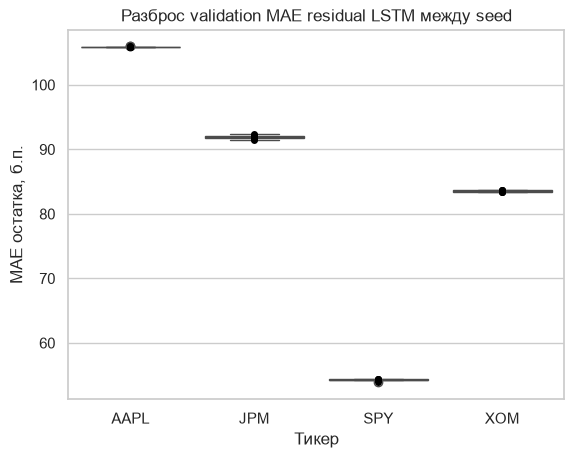

In [8]:
configuration_columns = ["ticker", "window", "units", "dropout"]
selected_residual_seed_metrics = residual_selection.run_metrics.merge(
    residual_selection.configurations.loc[:, configuration_columns],
    on=configuration_columns,
    how="inner",
    validate="many_to_one",
)
assert selected_residual_seed_metrics["status"].eq("ok").all()
assert selected_residual_seed_metrics.groupby("ticker")["seed"].nunique().eq(10).all()
ax = sns.boxplot(data=selected_residual_seed_metrics, x="ticker", y="mae_bps")
sns.stripplot(
    data=selected_residual_seed_metrics,
    x="ticker",
    y="mae_bps",
    color="black",
    jitter=False,
    ax=ax,
)
ax.set(
    title="Разброс validation MAE residual LSTM между seed",
    xlabel="Тикер",
    ylabel="MAE остатка, б.п.",
)
plt.show()

## Восстановление обычного LSTM ensemble

Ранее выполненные запуски загружаются из `artifacts/lstm_validation/`. Если совместимых checkpoint не хватает, функция продолжит только отсутствующие запуски.

In [9]:
ordinary_runs = run_lstm_grid(
    modeling_data,
    dataset_sha256,
    ORDINARY_LSTM_CHECKPOINT_DIR,
    trainer,
    progress=make_grid_progress("Ordinary LSTM grid"),
)
assert len(ordinary_runs) == EXPECTED_LSTM_RUNS
raw_baseline_predictions = (
    build_predictions(modeling_data, NaiveModel())
    .loc[lambda frame: frame["split"].eq("validation")]
    .reset_index(drop=True)
)
ordinary_selection = select_lstm_candidates(ordinary_runs, raw_baseline_predictions)
assert ordinary_selection.configurations["successful_seeds"].eq(10).all()
ordinary_selection.configurations

Ordinary LSTM grid: 480/480 | последний: checkpoint | прошло 0.0 мин | ETA: 0.0 мин


,ticker,window,units,dropout,successful_seeds,mean_mae_bps,mean_rmse_bps,std_mae_bps,parameter_count,model
0,AAPL,5,32,0.0,10,105.844797,153.521140,0.031948,4385,lstm
1,JPM,63,16,0.2,10,92.055264,130.408463,0.195891,1169,lstm
2,SPY,21,32,0.2,10,54.361614,80.981183,0.065361,4385,lstm
3,XOM,5,16,0.2,10,83.262807,113.819642,0.095385,1169,lstm


## Аддитивная композиция и проверки выравнивания

Гибрид складывает ARIMA forecast и прогноз следующего остатка только после строгой проверки observation keys и residual identity.

In [10]:
arima_predictions = arima_residual_data.arima_predictions.loc[
    lambda frame: frame["split"].eq("validation")
].reset_index(drop=True)
hybrid_predictions = build_arima_lstm_predictions(arima_predictions, residual_selection.predictions)
comparison = pd.concat(
    [
        raw_baseline_predictions,
        arima_predictions,
        ordinary_selection.predictions,
        hybrid_predictions,
    ],
    ignore_index=True,
)

expected_models = {"naive_zero", "arima", "lstm", "arima_lstm"}
assert set(comparison["model"]) == expected_models
assert comparison["split"].eq("validation").all()
assert not comparison["target_date"].isin(closed_target_dates).any()
assert np.isfinite(comparison[["actual_return", "predicted_return"]]).all().all()

alignment_columns = ["ticker", "date", "target_date", "split", "actual_return"]
baseline_keys = (
    raw_baseline_predictions.loc[:, alignment_columns]
    .sort_values(alignment_columns[:4])
    .reset_index(drop=True)
)
for model_name in sorted(expected_models - {"naive_zero"}):
    model_keys = (
        comparison.loc[comparison["model"].eq(model_name), alignment_columns]
        .sort_values(alignment_columns[:4])
        .reset_index(drop=True)
    )
    pd.testing.assert_frame_equal(model_keys, baseline_keys)

observation_counts = comparison.groupby(["model", "ticker"]).size().unstack(0)
assert observation_counts.nunique(axis=1).eq(1).all()
observation_counts

model,arima,arima_lstm,lstm,naive_zero
ticker,,,,
AAPL,1006,1006,1006,1006
JPM,1006,1006,1006,1006
SPY,1006,1006,1006,1006
XOM,1006,1006,1006,1006


In [11]:
validation_metrics = calculate_metrics(comparison)
metric_value_columns = [
    "observations",
    "mae_bps",
    "rmse_bps",
    "rel_mae",
    "oos_r2",
    "directional_accuracy",
]
assert np.isfinite(validation_metrics[metric_value_columns]).all().all()
validation_metrics.round(
    {
        "mae_bps": 3,
        "rmse_bps": 3,
        "rel_mae": 4,
        "oos_r2": 4,
        "directional_accuracy": 4,
    }
)

,split,ticker,model,observations,mae_bps,rmse_bps,rel_mae,oos_r2,directional_accuracy
0,validation,AAPL,arima,1006,105.899,153.525,0.9960,0.0046,0.5437
1,validation,JPM,arima,1006,92.351,130.760,1.0051,-0.0062,0.4970
2,validation,SPY,arima,1006,54.813,81.319,0.9996,0.0016,0.5249
3,validation,XOM,arima,1006,84.194,115.552,1.0099,-0.0309,0.5109
4,validation,ALL,arima,4024,84.314,123.119,1.0025,-0.0064,0.5191
5,validation,AAPL,arima_lstm,1006,105.862,153.533,0.9956,0.0045,0.5447
6,validation,JPM,arima_lstm,1006,91.824,130.214,0.9994,0.0021,0.5089
7,validation,SPY,arima_lstm,1006,54.053,80.495,0.9858,0.0218,0.5507
8,validation,XOM,arima_lstm,1006,83.494,114.120,1.0015,-0.0055,0.5060
9,validation,ALL,arima_lstm,4024,83.808,122.506,0.9965,0.0036,0.5276


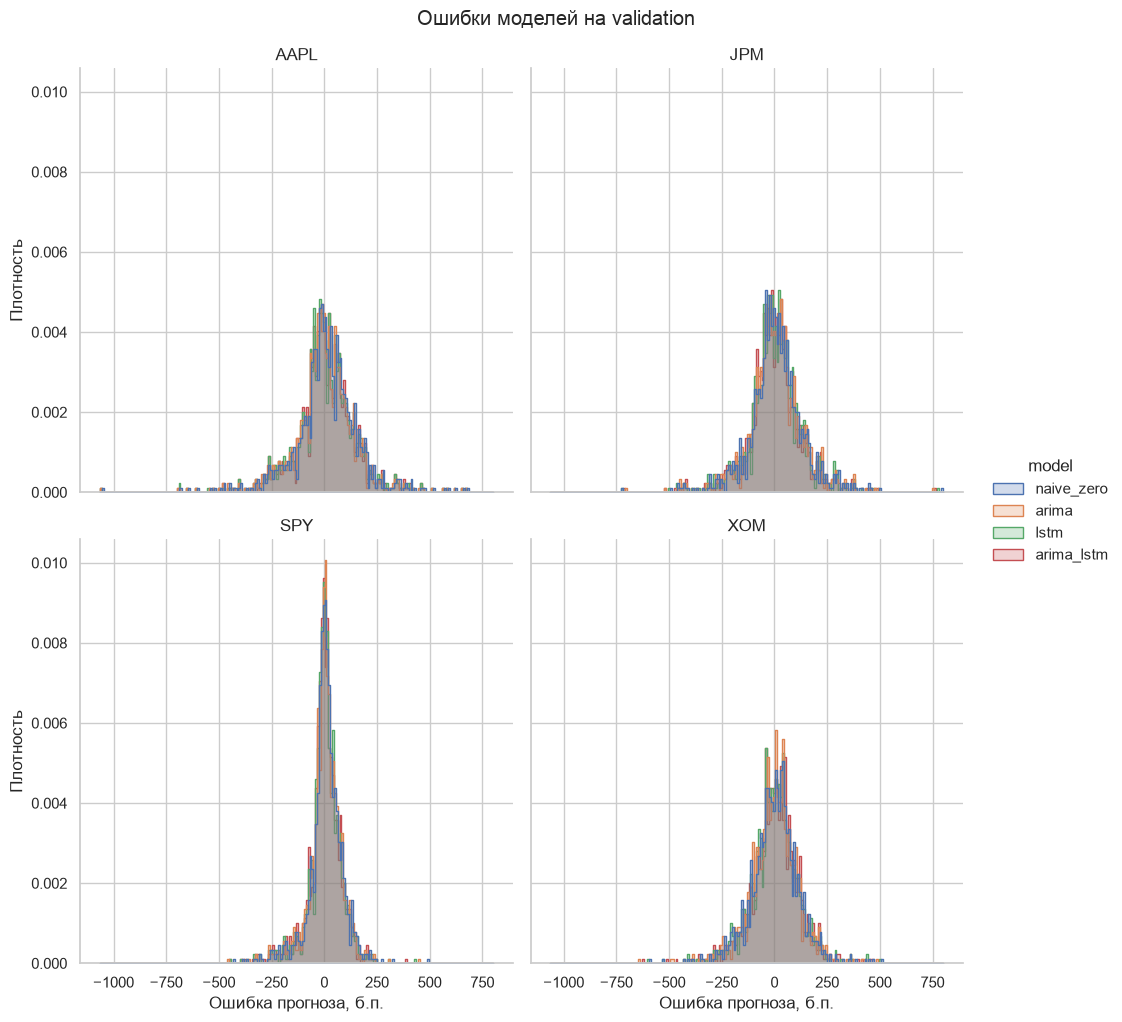

In [12]:
errors = comparison.assign(
    error_bps=(comparison["actual_return"] - comparison["predicted_return"]) * BPS_FACTOR
)
grid = sns.displot(
    data=errors,
    x="error_bps",
    hue="model",
    col="ticker",
    col_wrap=2,
    kind="hist",
    element="step",
    stat="density",
    common_norm=False,
)
grid.set_axis_labels("Ошибка прогноза, б.п.", "Плотность")
grid.set_titles("{col_name}")
grid.figure.suptitle("Ошибки моделей на validation", y=1.02)
plt.show()

## Ограничения интерпретации

- Validation использована для выбора residual LSTM, поэтому показанные метрики не являются независимой оценкой обобщения.
- Плохой результат ARIMA-LSTM не является основанием менять warm-up, grid, порядки ARIMA или правило выбора post hoc.
- Обычная и residual LSTM используют фиксированные train-веса и scaler, тогда как ARIMA переобучается ежедневно.
- Гибрид аддитивный, не обучается end-to-end и не использует внешние признаки.
- Final test не открывался; notebook не содержит свидетельств итогового качества моделей.